# Sin Desadaptación

### Datos

In [3]:
Γs = -0.41      #Coeficiente Reflexion del generador
Γl = 1          #Coeficiente Reflexion de la carga
vi = 0.7059
tof = 1       #Time of Flight
t_max = 11  #Grafica hasta t_max τ

### Diagrama de Lattice

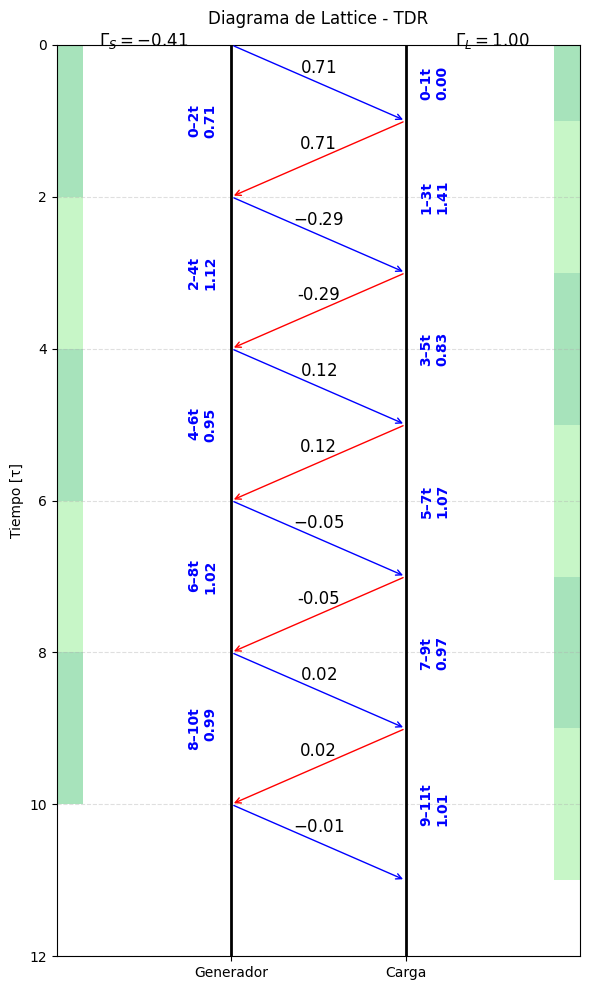

In [4]:
import matplotlib.pyplot as plt

#Clases
class signal:
    def __init__(self, start, direction, voltage):
        self.start = start
        self.direction = direction
        self.voltage = voltage


class wall:
    def __init__(self, Γ, vi):
        self.Γ = Γ
        self.times = [-1, 0]
        self.impacts = []
        self.voltages = [0, vi]

    def agregar_impacto(self, time, impact):
      self.times.append(time)
      self.impacts.append(impact)

    def process_impacts(self):
        for i in range(len(self.impacts)):
            self.voltages.append(self.voltages[-1] + self.impacts[i] * (1 + self.Γ))


#Variables
s = signal(0, "G→L", vi)
wall_g = wall(Γs, vi)
wall_l = wall(Γl, 0)
time_range_colors = ['#90EE90', '#50C878']

#Figura
fig, ax = plt.subplots(figsize=(6, 10))

while s.start < t_max:
  if s.direction == "G→L":

    #Parámetros Flecha
    x_start, x_end = 0, 1
    y_start, y_end = s.start, s.start + tof
    arrow_color = "blue"

    #Crear Impacto
    wall_l.agregar_impacto(y_end, s.voltage)

    #Actualizar datos
    s.direction = "L→G"
    s.start += tof
    s.voltage *= Γl
    if(Γl == 0):
      s.start = t_max

  elif s.direction == "L→G":
    #Parámetros Flecha
    x_start, x_end = 1, 0
    y_start, y_end = s.start, s.start + tof
    arrow_color = "red"

    #Crear Impacto
    wall_g.agregar_impacto(y_end, s.voltage)

    #Actualizar datos
    s.direction = "G→L"
    s.voltage *= Γs
    s.start += tof
    if(Γs == 0):
        s.start = t_max

  #Dibujar Flecha
  ax.annotate("", xy=(x_end, y_end), xytext=(x_start, y_start), arrowprops=dict(arrowstyle='->', color=arrow_color))

#Calcular Valores Tensión
wall_g.process_impacts()
wall_l.process_impacts()

#Graficar Valores Reflexiones
for i in range(len(wall_g.impacts)):
  ax.text(0.5, wall_g.times[i+2]-tof/2-0.2, f'{wall_g.impacts[i]:.2f}', ha='center', va='center', fontsize=12, color='black')
for i in range(len(wall_l.impacts)):
  ax.text(0.5, wall_l.times[i+2]-tof/2-0.2, f'${wall_l.impacts[i]:.2f}$', ha='center', va='center', fontsize=12, color='black')

#Graficar Valores de Tensión
for i in range(1, len(wall_g.voltages)-1):
  ax.axhspan(wall_g.times[i+1], wall_g.times[i], xmin=0, xmax=0.05, facecolor=time_range_colors[i%2], alpha=0.5, zorder=0)
  ax.text(-0.08, (wall_g.times[i+1] + wall_g.times[i]) / 2, f'{wall_g.times[i]}–{wall_g.times[i+1]}t\n{wall_g.voltages[i]:.2f}', ha='right', va='center', fontsize=10, rotation=90, color='blue', fontweight='bold')
for i in range(1, len(wall_l.voltages)-1):
  ax.axhspan(wall_l.times[i+1], wall_l.times[i], xmin=0.95, xmax=1, facecolor=time_range_colors[i%2], alpha=0.5, zorder=0)
  ax.text(1.08, (wall_l.times[i+1] + wall_l.times[i]) / 2, f'{wall_l.times[i]}–{wall_l.times[i+1]}t\n{wall_l.voltages[i]:.2f}', ha='left', va='center', fontsize=10, rotation=90, color='blue', fontweight='bold')

#Líneas verticales
ax.vlines(x=0, ymin=-1, ymax=t_max + tof, color='black', linestyle='-', linewidth=2)
ax.vlines(x=1, ymin=-1, ymax=t_max + tof, color='black', linestyle='-', linewidth=2)

#Coeficientes de reflexión
ax.text(-0.5, -0.05, f'$\\Gamma_S = {Γs:.2f}$', ha='center', va='center', fontsize=12)
ax.text(1.5, -0.05, f'$\\Gamma_L = {Γl:.2f}$', ha='center', va='center', fontsize=12)

#Estética
ax.set_xlim(-1, 2)
ax.set_ylim(t_max + tof, 0)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Generador", "Carga"])
ax.set_ylabel("Tiempo [τ]")
ax.set_title("Diagrama de Lattice - TDR", pad=15)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

#Graficar
plt.tight_layout()
plt.show()

### Gráficos Temporales

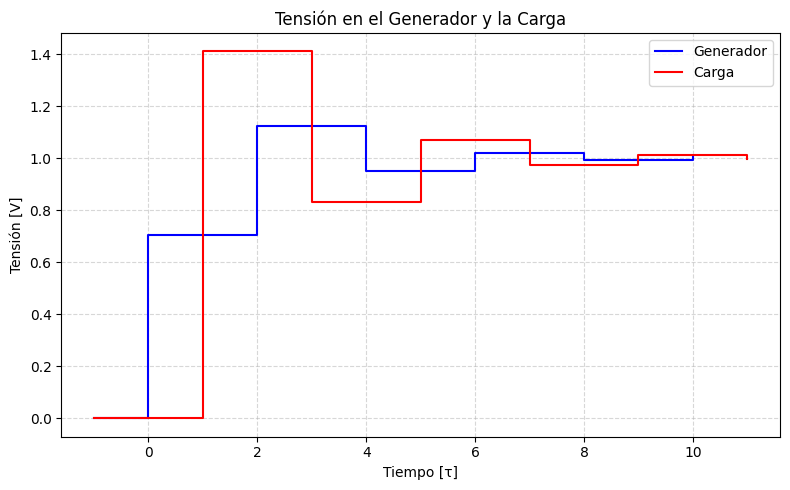

In [5]:
# Graficar señales
plt.figure(figsize=(8, 5))
plt.step(wall_g.times, wall_g.voltages, where='post', label='Generador', color='blue')
plt.step(wall_l.times, wall_l.voltages, where='post', label='Carga', color='red')

plt.title('Tensión en el Generador y la Carga')
plt.xlabel('Tiempo [τ]')
plt.ylabel('Tensión [V]')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Desadaptación

### Datos

In [6]:
Γ1 = -0.3007     #Coeficiente Reflexion del generador
Γ2 = -0.3007    #Coeficiente Reflexion desde izquierda
Γ3 = +0.3007   #Coeficiente Reflexion desde derecha
Γ4 = 1      #Coeficiente Reflexion de la carga
vi = 2.34
tof1 = 32.5
tof2 = 32.5
t_max = 10  #Grafica hasta t_max τ

### Diagrama de Lattice

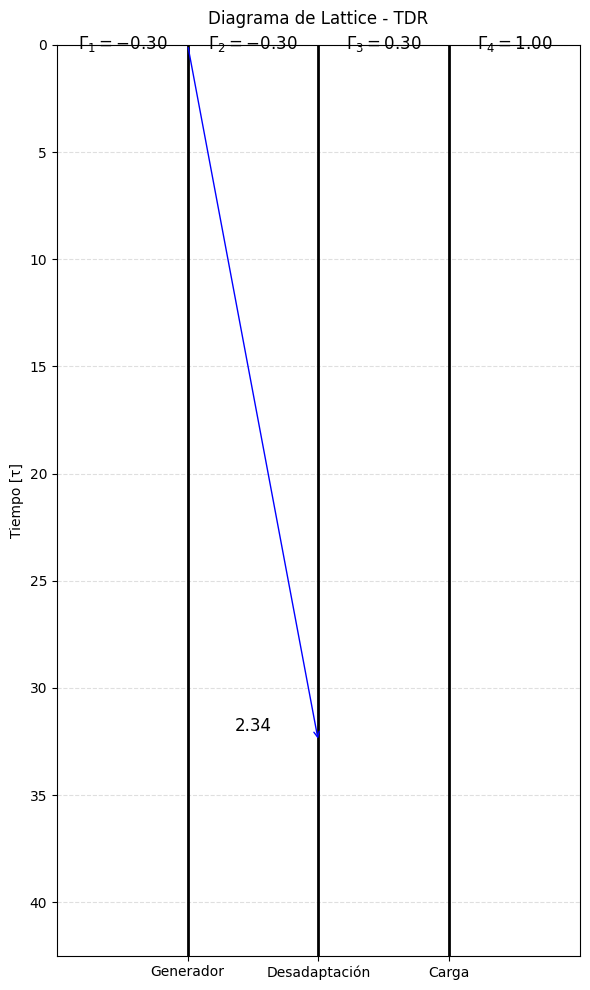

In [7]:
import matplotlib.pyplot as plt
import bisect

#Clases
class signal:
    def __init__(self, start, direction, voltage):
        self.start = start
        self.direction = direction
        self.voltage = voltage


class wall:
    def __init__(self, Γ, vi):
        self.Γ = Γ
        self.times = [-1, 0]
        self.impacts = []
        self.voltages = [0, vi]

    def agregar_impacto(self, time, impact):
      if time in self.times:
        indice = self.times.index(time) - 2
        self.impacts[indice] += impact
      else:
        pos = bisect.bisect(self.times, time)
        self.times.insert(pos, time)
        self.impacts.insert(pos, impact)

    def process_impacts(self):
        for i in range(len(self.impacts)):
            self.voltages.append(self.voltages[-1] + self.impacts[i] * (1 + self.Γ))

#Variables
signals = []
colors = ["orange", "blue", "green", "red", "purple", "brown", "olive", "cyan", "magenta", "teal", "gold", "navy", "lime", "coral", "darkgreen", "darkred", "slateblue", "chocolate"]
wall_g = wall(Γ1, vi)
wall_m_l = wall(Γ2, 0)
wall_m_r = wall(Γ3, 0)
wall_l = wall(Γ4, 0)

#Figura
fig, ax = plt.subplots(figsize=(6, 10))

#Cálculo de valores
signals.append(signal(0, "G→M", vi))

i = 0
for s in signals:
  i += 1
  arrow_color = colors[i % len(colors)]
  while s.start < t_max:
    if s.direction == "G→M":

      #Parámetros Flecha
      x_start, x_end = 0, 1
      y_start, y_end = s.start, s.start + tof1

      #Crear Impacto
      wall_m_l.agregar_impacto(y_end, s.voltage)

      #Actualizar datos
      s.direction = "M→G"
      s.start += tof1
      signals.append(signal(s.start, "M→L", s.voltage * (1 + Γ2))) #Nuevo Objeto
      s.voltage *= Γ2
      if(Γ2 == 0):
        s.start = t_max

    elif s.direction == "M→G":
      #Parámetros Flecha
      x_start, x_end = 1, 0
      y_start, y_end = s.start, s.start + tof1

      #Crear Impacto
      wall_g.agregar_impacto(y_end, s.voltage)

      #Actualizar datos
      s.direction = "G→M"
      s.voltage *= Γ1
      s.start += tof1
      if(Γ1 == 0):
        s.start = t_max

    elif s.direction == "M→L":
      #Parámetros Flecha
      x_start, x_end = 1, 2
      y_start, y_end = s.start, s.start + tof2

      #Crear Impacto
      wall_l.agregar_impacto(y_end, s.voltage)

      #Actualizar datos
      s.direction = "L→M"
      s.voltage *= Γ4
      s.start += tof2
      if(Γ4 == 0):
        s.start = t_max

    elif s.direction == "L→M":
      #Parámetros Flecha
      x_start, x_end = 2, 1
      y_start, y_end = s.start, s.start + tof2

      #Crear Impacto
      wall_m_r.agregar_impacto(y_end, s.voltage)

      #Actualizar datos
      s.direction = "M→L"
      s.start += tof2
      signals.append(signal(s.start, "M→G", s.voltage * (1 + Γ3))) #Nuevo Objeto
      s.voltage *= Γ3
      if(Γ3 == 0):
        s.start = t_max

    #Dibujar Flecha
    ax.annotate("", xy=(x_end, y_end), xytext=(x_start, y_start), arrowprops=dict(arrowstyle='->', color=arrow_color))

#Calcular Valores Tensión
wall_g.process_impacts()
wall_m_l.process_impacts()
wall_m_r.process_impacts()
wall_l.process_impacts()

#Graficar Valores Reflexiones
for i in range(len(wall_g.impacts)):
  ax.text(0.5, wall_g.times[i+2]-tof/2-0.2, f'{wall_g.impacts[i]:.2f}', ha='center', va='center', fontsize=12, color='black')
for i in range(len(wall_m_l.impacts)):
  ax.text(0.5, wall_m_l.times[i+2]-tof/2-0.2, f'{wall_m_l.impacts[i]:.2f}', ha='center', va='center', fontsize=12, color='black')
for i in range(len(wall_m_r.impacts)):
  ax.text(1.5, wall_m_r.times[i+2]-tof/2-0.2, f'${wall_m_r.impacts[i]:.2f}$', ha='center', va='center', fontsize=12, color='black')
for i in range(len(wall_l.impacts)):
  ax.text(1.5, wall_l.times[i+2]-tof/2-0.2, f'${wall_l.impacts[i]:.2f}$', ha='center', va='center', fontsize=12, color='black')

#Graficar Valores de Tensión
for i in range(1, len(wall_g.voltages)-1):
  ax.axhspan(wall_g.times[i+1], wall_g.times[i], xmin=0, xmax=0.05, facecolor=time_range_colors[i%2], alpha=0.5, zorder=0)
  ax.text(-0.08, (wall_g.times[i+1] + wall_g.times[i]) / 2, f'{wall_g.times[i]}–{wall_g.times[i+1]}τ\n{wall_g.voltages[i]:.2f}', ha='right', va='center', fontsize=10, rotation=90, color='blue', fontweight='bold')
for i in range(1, len(wall_l.voltages)-1):
  ax.axhspan(wall_l.times[i+1], wall_l.times[i], xmin=0.95, xmax=1, facecolor=time_range_colors[i%2], alpha=0.5, zorder=0)
  ax.text(2.08, (wall_l.times[i+1] + wall_l.times[i]) / 2, f'{wall_l.times[i]}–{wall_l.times[i+1]}τ\n{wall_l.voltages[i]:.2f}', ha='left', va='center', fontsize=10, rotation=90, color='blue', fontweight='bold')

#Líneas verticales
ax.vlines(x=0, ymin=-1, ymax=t_max + max(tof1, tof2), color='black', linestyle='-', linewidth=2)
ax.vlines(x=1, ymin=-1, ymax=t_max + max(tof1, tof2), color='black', linestyle='-', linewidth=2)
ax.vlines(x=2, ymin=-1, ymax=t_max + max(tof1, tof2), color='black', linestyle='-', linewidth=2)

#Coeficientes de reflexión
ax.text(-0.5, -0.05, f'$\\Gamma_1 = {Γ1:.2f}$', ha='center', va='center', fontsize=12)
ax.text(0.5, -0.05, f'$\\Gamma_2 = {Γ2:.2f}$', ha='center', va='center', fontsize=12)
ax.text(1.5, -0.05, f'$\\Gamma_3 = {Γ3:.2f}$', ha='center', va='center', fontsize=12)
ax.text(2.5, -0.05, f'$\\Gamma_4 = {Γ4:.2f}$', ha='center', va='center', fontsize=12)

#Estética
ax.set_xlim(-1, 3)
ax.set_ylim(t_max + max(tof1, tof2), 0)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Generador", "Desadaptación", "Carga"])
ax.set_ylabel("Tiempo [τ]")
ax.set_title("Diagrama de Lattice - TDR", pad=15)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

#Graficar
plt.tight_layout()
plt.show()

### Gráficos Temporales

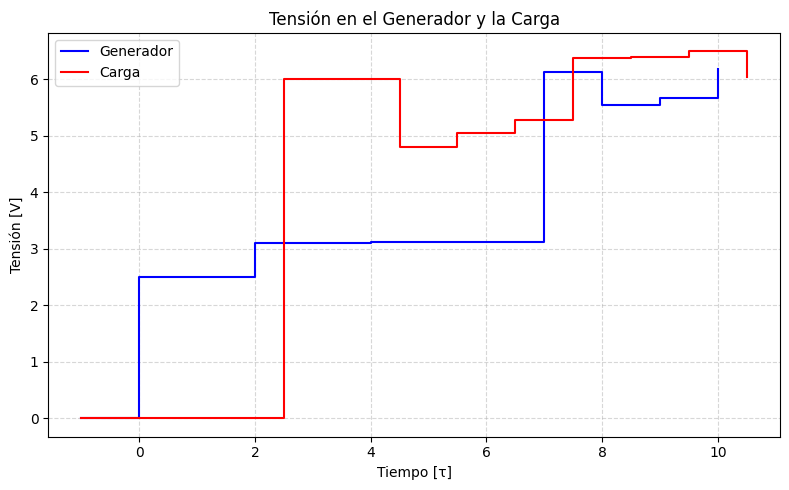

In [ ]:
# Graficar señales
plt.figure(figsize=(8, 5))
plt.step(wall_g.times, wall_g.voltages, where='post', label='Generador', color='blue')
plt.step(wall_l.times, wall_l.voltages, where='post', label='Carga', color='red')

plt.title('Tensión en el Generador y la Carga')
plt.xlabel('Tiempo [τ]')
plt.ylabel('Tensión [V]')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Ejercicios

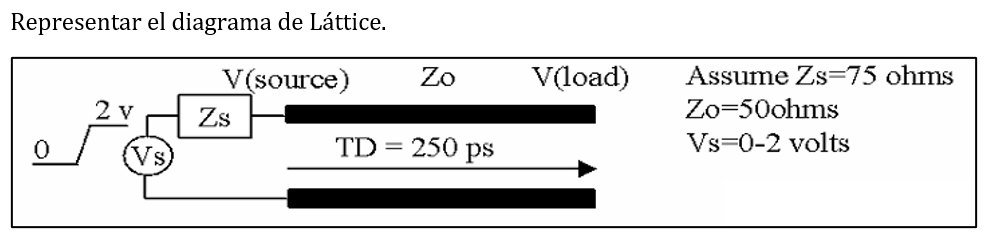

In [ ]:
z0 = 50
zs = 75
vs = 2
Γs = (zs-z0)/(zs+z0)
Γl = 1
vi = vs * z0/(z0+zs)
tof = 250
t_max = 5*tof

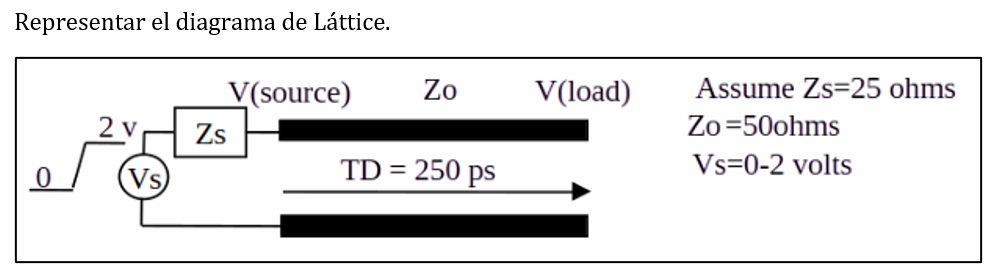

In [ ]:
z0 = 50
zs = 25
vs = 2
Γs = (zs-z0)/(zs+z0)
Γl = 1
vi = vs * z0/(z0+zs)
tof = 250
t_max = 7*tof

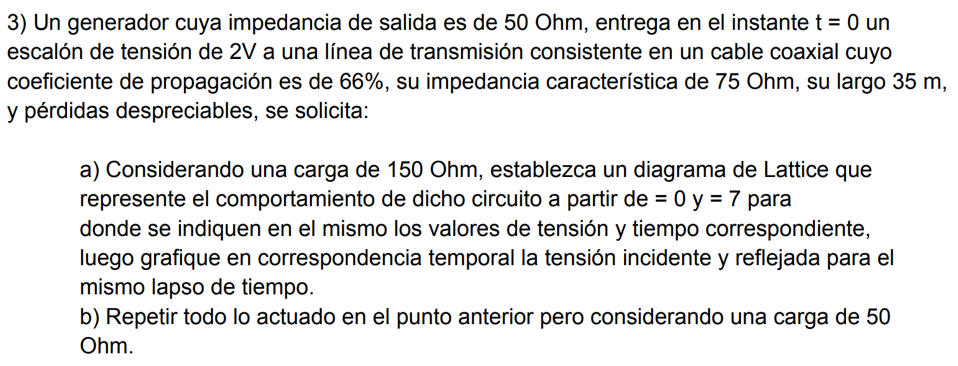

In [ ]:
z0 = 75
zs = 50
zl = 150
vs = 2
Γs = (zs-z0)/(zs+z0)
Γl = (zl-z0)/(zl+z0)
vi = vs * z0/(z0+zs)
tof = 175
t_max = 7*tof

In [ ]:
z0 = 75
zs = 50
zl = 50
vs = 2
Γs = (zs-z0)/(zs+z0)
Γl = (zl-z0)/(zl+z0)
vi = vs * z0/(z0+zs)
tof = 175
t_max = 7*tof

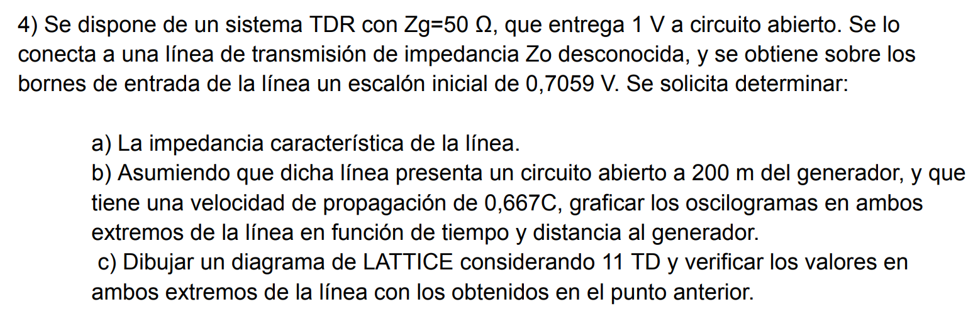

In [ ]:
z0 = 75
zs = 50
zl = 50
vs = 1
vi = 0.7059
z0 = zs/((vs/vi)-1)
Γs = (zs-z0)/(zs+z0)
Γl = 1
tof = 1
t_max = 11*tof

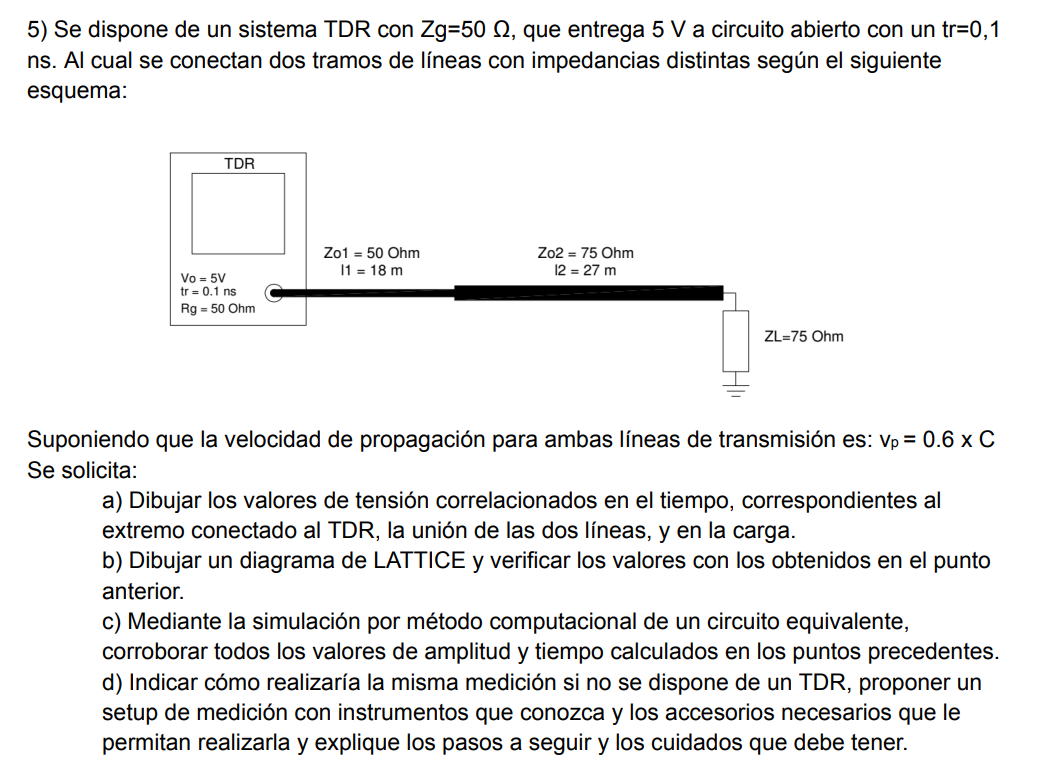

In [ ]:
Γ1 = 0      #Coeficiente Reflexion del generador
Γ2 = 0.2    #Coeficiente Reflexion desde izquierda
Γ3 = -0.2   #Coeficiente Reflexion desde derecha
Γ4 = 0      #Coeficiente Reflexion de la carga
vi = 2.5
tof1 = 1
tof2 = 1.5
t_max = 10  #Grafica hasta t_max τ